# Driver

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import scipy as sp
import itertools
from itertools import combinations
import copy
import pandas
import gudhi

In [74]:
from Alexander_subdivision import *

In [75]:
df = pandas.read_csv('pointclouds_rat_brain_no_myelin0_image.csv')

In [76]:
points = df.to_numpy()[:,1:]

In [77]:
points.shape

(53096, 2)

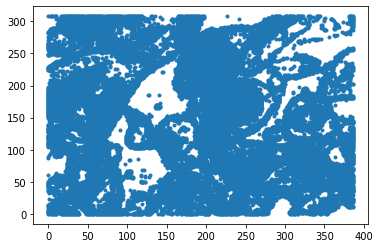

In [78]:
plt.plot(points[:,0], points[:,1], '.')

In [79]:
# Bounding box
mins = points.min(axis=0)
maxs = points.max(axis=0)

# Midpoints
mids = (mins + maxs) / 2

mask = (
    (points[:, 0] <= mids[0]) &
    (points[:, 1] <= mids[1])
)

points_subset = points[mask]

# 3. Aggressive subsampling: keep 1 out of every 10 points
points_subsampled = points_subset[::10]


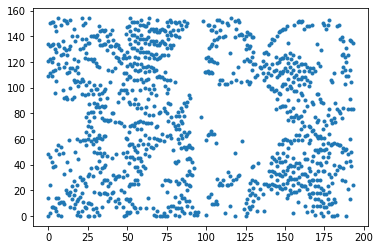

In [80]:
plt.plot(points_subsampled[:,0], points_subsampled[:,1], '.')

In [81]:
points_subsampled.shape

(1217, 2)

In [82]:
points_subsampled *= 0.05

In [83]:
ac = gudhi.AlphaComplex(points=points_subsampled)
st = ac.create_simplex_tree()

# Compute persistence
diag = st.persistence()

In [84]:
pd0 = [x[1] for x in diag if x[0] == 0]
pd1 = [x[1] for x in diag if x[0] == 1]

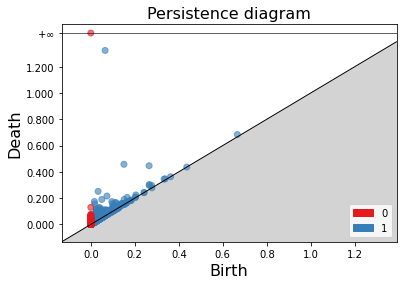

In [85]:
gudhi.plot_persistence_diagram(diag)
plt.show()

In [86]:
L = getAlphaComplex(points_subsampled, .5)

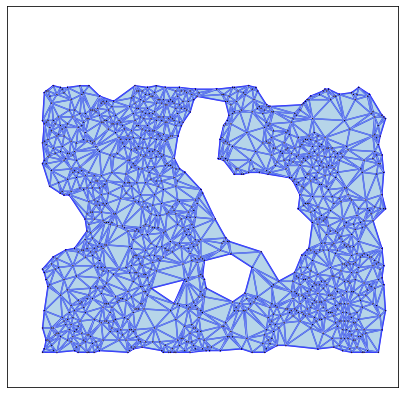

In [87]:
draw_2d_simplicial_complex(L, points_subsampled)

In [88]:
M = getAlphaComplex(points_subsampled, 1.2)

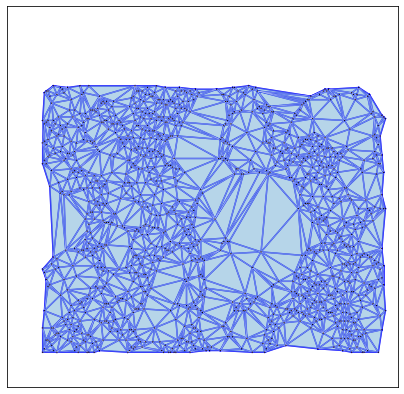

In [89]:
draw_2d_simplicial_complex(M, points_subsampled)

In [92]:
MminusL = [ x for x in M if x not in L ]


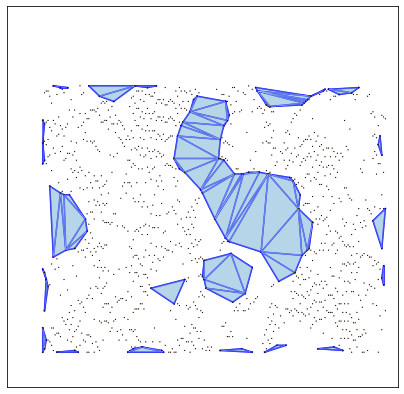

In [93]:
draw_2d_simplicial_complex(MminusL, points_subsampled)

## Build slanted L, then the supplement from that
$\mathcal{L} := L \cup L_{out}$ with $L_{out}$ being the simplices in $M$ that share no vertex with $L$: <br>
$L_{out} := \{ \sigma \in M \ | \ \sigma \cap L_0 = \emptyset  \}$

In [94]:
L0 = list(set( [ vert for sigma in L for vert in sigma ] ))
Lout = [ simp for simp in M if all( x not in L0 for x in simp)  ]

In [96]:
len(Lout)

0

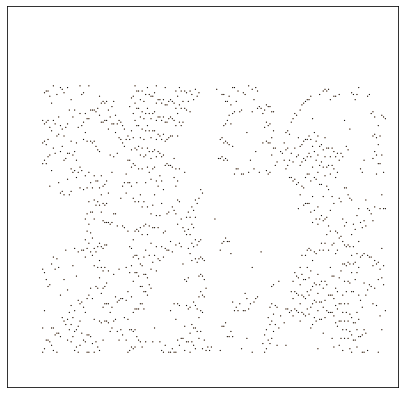

In [97]:
draw_2d_simplicial_complex(Lout, points_subsampled)

## Problem! With a common vertex set, $L_{out}$ is always empty

In [35]:
%load_ext IPython.extensions.autoreload
%autoreload 2

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [36]:
import Alexander_subdivision

In [98]:
relsub, newpoints = RelSub(M, points_subsampled, L, points_subsampled);

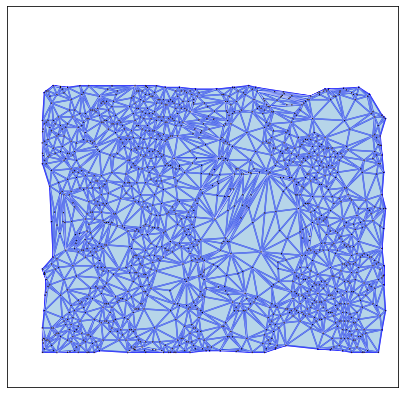

In [99]:
draw_2d_simplicial_complex(relsub, newpoints)

In [100]:
sM, sMPoints = subdivision(M, points_subsampled)

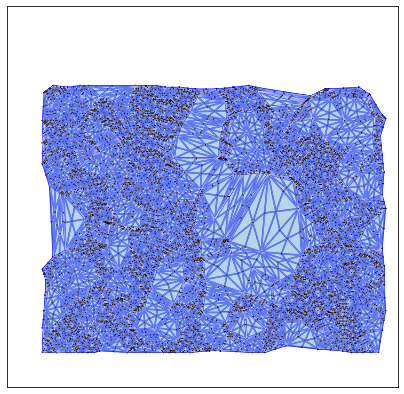

In [101]:
draw_2d_simplicial_complex(sM, sMPoints)

In [102]:
LbarTight, indices = tightSupp(L, points_subsampled, M, points_subsampled)

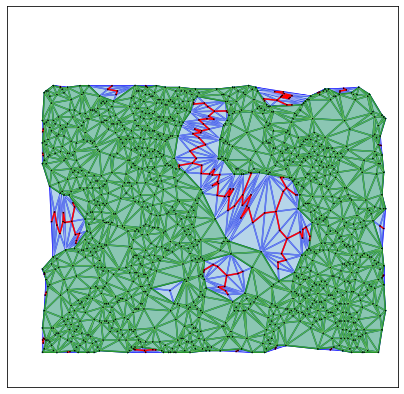

In [103]:
draw_Sup( relsub , L , LbarTight, indices, pos = newpoints, posSub = points_subsampled)

In [104]:
EL = [ x for x in relsub if len(x)==2 ]
EL = list(sorted(EL))

Triangles = [ x for x in relsub if len(x)==3 ]
Triangles = list(sorted(Triangles))

In [105]:
BoundaryOfTriangles = np.zeros( ( len(EL), len(Triangles) ), dtype=int)


for i,T in enumerate(Triangles):


    e0 = EL.index( [T[0], T[1]] )
    e1 = EL.index( [T[1], T[2]] )
    e2 = EL.index( [T[0], T[2]] )

    BoundaryOfTriangles[ e0 , i ] = 1
    BoundaryOfTriangles[ e1 , i ] = 1
    BoundaryOfTriangles[ e2 , i ] = 1

In [106]:
outerCycle = np.sum( BoundaryOfTriangles, axis = 1 )
outerCycle = np.mod(outerCycle, 2)

In [107]:
markedEdges = [ e for i,e in enumerate(EL) if outerCycle[i]==1 ]

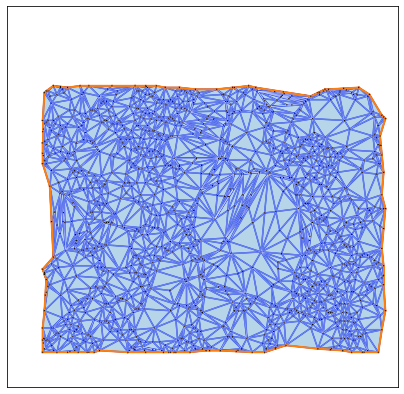

In [108]:
draw_2d_simplicial_complex(relsub, newpoints, markedEdges=markedEdges)

In [109]:
LbarCopy = copy.deepcopy(LbarTight)
Lbar;

In [110]:
Vertices = [ s for s in LbarCopy if len(s) == 1 ]
Vertices;

In [111]:
Edges = [ s for s in LbarCopy if len(s) == 2 ]
Edges;

In [112]:
CC = Vertices
CC;

Iterate over all edges. For each, find which connected components contains the source and which the target. IF THEY ARE DIFFERENT, join them into source and delete target.

In [142]:
for e in Edges:
    
    source = next(i for i,c in enumerate(CC) if e[0] in c )
    target = next(i for i,c in enumerate(CC) if e[1] in c )
    
    if source != target:
        CC[source].extend( CC[target] )
        del CC[target]

23

In [145]:
BanishedVertices = set()

for e in markedEdges:
    BanishedVertices.add( e[0] )
    BanishedVertices.add( e[1] )
    
BanishedVertices = list(sorted(BanishedVertices))


In [146]:
ValidCC = []
ExcludeCC = []

for c in CC:
    
    if any( v in BanishedVertices for v in c ):
        
        ExcludeCC.append(c)
    else:
        
        ValidCC.append(c)

In [147]:
len(ValidCC)

3

In [148]:
len(ExcludeCC)

20

### Exclude a vertex if its connected component contains any from the banished vertices

In [149]:
excludedVerts = []

list(excludedVerts.extend(c) for c in ExcludeCC)
excludedVerts;

In [151]:
len(excludedVerts)

74

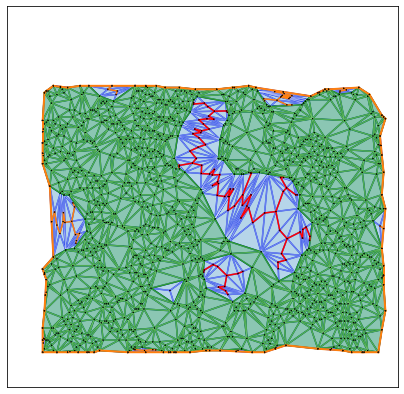

In [152]:
draw_Sup( relsub , L , LbarTight, indices, pos = newpoints, posSub = points_subsampled, boundaryComponent = markedEdges, excludedVerts=excludedVerts )

In [180]:
ValidCC[0]

[1217]

In [132]:
offset = points_subsampled.shape[0]
ReprEdges = []

EL = [ x for x in M if len(x)==2 ]
EL = list(sorted(EL))

for simps in ValidCC:
    
    ReprTriangles = []
   
    for s in simps:

        simplex = M[s - offset]
        if len(simplex) == 3:

            ReprTriangles.append(simplex)

    
    Boundary = np.zeros( ( len(EL), len(ReprTriangles) ), dtype=int)

    for i,T in enumerate(ReprTriangles):

        e0 = EL.index( [T[0], T[1]] )
        e1 = EL.index( [T[0], T[2]] )
        e2 = EL.index( [T[1], T[2]] )
        
        Boundary[ e0 , i ] = 1
        Boundary[ e1 , i ] = 1
        Boundary[ e2 , i ] = 1
    
    outerCycle = np.sum( Boundary, axis = 1 )
    outerCycle = np.mod(outerCycle, 2)
    
    ReprEdges.extend([ e for i,e in enumerate(EL) if outerCycle[i]==1 ] )
        

In [ ]:
ValidCC[1]

In [166]:
RepTri = []
for s in ValidCC[1]:

    simplex = M[s-offset]
    RepTri.append(simplex)
    

In [170]:
Boundary = np.zeros( ( len(EL), len(ReprTriangles) ), dtype=int)

In [173]:
for i,T in enumerate(RepTri):

    e0 = EL.index( [T[0], T[1]] )
    e1 = EL.index( [T[0], T[2]] )
    e2 = EL.index( [T[1], T[2]] )
    
    Boundary[ e0 , i ] = 1
    Boundary[ e1 , i ] = 1
    Boundary[ e2 , i ] = 1
    
outerCycle = np.sum( Boundary, axis = 1 )
outerCycle = np.mod(outerCycle, 2)

ReprEdges.extend([ e for i,e in enumerate(EL) if outerCycle[i]==1 ] )

In [174]:
ReprEdges

[[691, 697],
 [691, 703],
 [697, 703],
 [5, 11],
 [5, 17],
 [11, 17],
 [170, 178],
 [170, 195],
 [178, 195],
 [231, 241],
 [231, 250],
 [241, 250],
 [323, 330],
 [323, 350],
 [330, 350],
 [486, 494],
 [486, 502],
 [494, 502],
 [530, 537],
 [530, 544],
 [531, 538],
 [531, 545],
 [537, 544],
 [538, 545],
 [621, 628],
 [621, 643],
 [628, 643],
 [824, 828],
 [824, 832],
 [828, 832],
 [884, 893],
 [884, 902],
 [893, 902],
 [1182, 1188],
 [1182, 1194],
 [1188, 1194],
 [4, 10],
 [4, 16],
 [5, 17],
 [5, 23],
 [10, 16],
 [12, 18],
 [12, 24],
 [17, 23],
 [18, 24],
 [43, 48],
 [43, 52],
 [48, 52],
 [63, 68],
 [63, 79],
 [68, 79],
 [94, 100],
 [94, 107],
 [100, 107],
 [103, 110],
 [103, 116],
 [110, 116],
 [118, 124],
 [118, 130],
 [124, 130],
 [174, 182],
 [174, 191],
 [182, 191],
 [196, 204],
 [196, 213],
 [204, 213],
 [220, 230],
 [220, 240],
 [221, 231],
 [221, 241],
 [226, 236],
 [226, 246],
 [228, 238],
 [228, 248],
 [230, 240],
 [231, 241],
 [232, 242],
 [232, 251],
 [233, 243],
 [233, 252]

In [167]:
M[1217-offset]

[691, 697, 703]

In [162]:
ReprEdges.index([697,703])

2

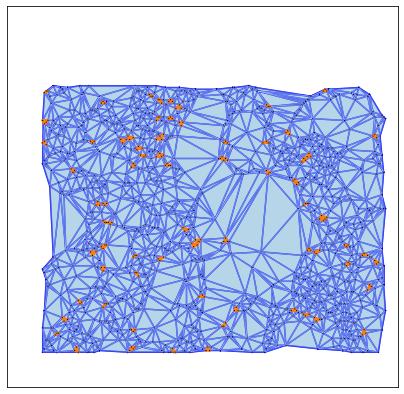

In [175]:
draw_2d_simplicial_complex(M, points_subsampled, markedEdges=ReprEdges)